In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
from tqdm import tqdm

In [ ]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np


class TenArmedBanditEnv(gym.Env):
    metadata = {"render_modes": []}
    def __init__(self, k=10):
        super().__init__()
        self.k = k
        self.q_star = np.random.normal(0, 1, size=k)
        self.action_space = spaces.Discrete(k)
        self.observation_space = spaces.Box( # Since bandits have no state, hence return 0 by default
            low=0,
            high=0,
            shape=(1,),
            dtype=np.float32,
        )

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.q_star = np.random.normal(0, 1, self.k)
        return np.array([0.0], dtype=np.float32), {}

    def step(self, action):
        reward = np.random.normal(self.q_star[action], 1.0)
        observation = np.array([0.0], dtype=np.float32)
        terminated = False # For the terminal state -> A bandit never reaches a terminal state
        truncated = False # Indicates the end of an episode due to external limit (eg max number of steps)

        return observation, reward, terminated, truncated, {}

In [ ]:
class GreedyAgent:
    def __init__(self, k=10):
        self.q_values = np.zeros(k)
        self.arm_count = np.zeros(k)
        self.last_action = None

    def agent_start(self):
        action = np.argmax(self.q_values)
        self.last_action = action
        return action

    def agent_step(self, reward):
        self.arm_count[self.last_action] += 1
        step_size = 1 / self.arm_count[self.last_action]
        self.q_values[self.last_action] += step_size * (
            reward - self.q_values[self.last_action]
        )
        action = np.argmax(self.q_values)
        self.last_action = action
        return action

In [7]:
env = TenArmedBanditEnv()

agent = GreedyAgent()

obs, info = env.reset()

action = agent.agent_start()

rewards = []

for t in range(1000):
    obs, reward, terminated, truncated, info = env.step(action)
    rewards.append(reward)
    action = agent.agent_step(reward)

In [8]:
runs = 2000
steps = 1000

avg_rewards = np.zeros(steps)

for run in range(runs):
    env = TenArmedBanditEnv()
    agent = GreedyAgent()
    env.reset()
    action = agent.agent_start()
    for step in range(steps):
        _, reward, _, _, _ = env.step(action)
        avg_rewards[step] += reward
        action = agent.agent_step(reward)

avg_rewards /= runs

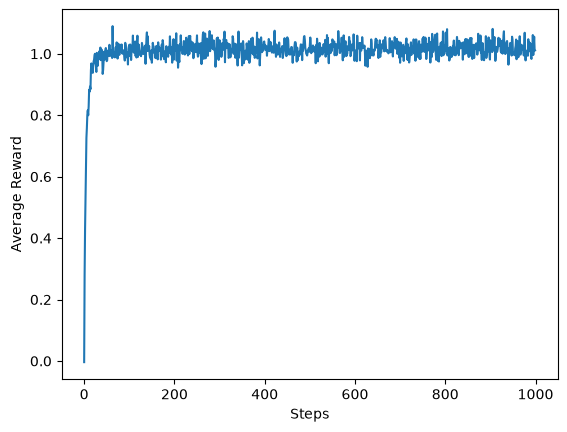

In [9]:
plt.plot(avg_rewards)
plt.xlabel("Steps")
plt.ylabel("Average Reward")
plt.show()